특성 데이터 ($\mathbf{X}$): alcohol, malic_acid 등의 13가지 화학적 수치

타겟 ($\mathbf{y}$): 0, 1, 2 (와인 종류를 나타내는 레이블)

- 0,class_0,와인 품종 1 (이탈리아 같은 지역의 품종)
- 1,class_1,와인 품종 2 (이탈리아 같은 지역의 품종)
- 2,class_2,와인 품종 3 (이탈리아 같은 지역의 품종)


| 특성 이름 (Feature Name) | 설명 (Description) | 단위 / 형식 | 중요도 (일반적) |
| --- | --- | --- | --- |
| **alcohol** | 알코올 함량 | % vol (볼륨 기준) | 높음 |
| **malic_acid** | 말산 함량 | g/L | 보통 |
| **ash** | 회분 (재) 함량 | g/L | 낮음 |
| **alcalinity_of_ash** | 회분의 알칼리도 (Ph) | pH 값 | 보통 |
| **magnesium** | 마그네슘 함량 | mg/L | 보통 |
| **total_phenols** | 총 페놀류 함량 (항산화 물질) | - | 높음 |
| **flavanoids** | 플라보노이드 함량 (페놀류의 일종) | - | **매우 높음** |
| **nonflavanoid_phenols** | 비(非) 플라보노이드 페놀류 함량 | - | 낮음 |
| **proanthocyanins** | 프로안토시아닌 함량 (탄닌 성분) | - | 보통 |
| **color_intensity** | 색상의 강도 (색이 진한 정도) | - | 높음 |
| **hue** | 색상 (채도, 특정 파장에서의 색조) | - | 높음 |
| **od280/od315_of_diluted_wines** | 희석된 와인에서 280nm와 315nm 파장 흡광도의 비율. 와인 단백질 측정 지표. | - | 높음 |
| **proline** | 프롤린 함량 (아미노산의 일종) | mg/L | **매우 높음** |

---

특성 중요도 관련 참고 사항: **`flavanoids`** 와 **`proline`** 은 일반적으로 와인의 품종을 분류하는 데 있어 **가장 중요한 특성**으로 알려져 있다. 플라보노이드는 와인의 맛과 색상에, 프롤린은 와인의 아미노산 구성에 큰 영향을 미친다.


```text

logistic, tree, knn 각각에 대해 결과 확인
1. train, test나누기
2. scale 하기
3. train, test 측정값확인하기( confusion은 heatmap 포함)

In [898]:
from sklearn.datasets import load_wine
import pandas as pd
wine = load_wine()

wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_df['target'] = wine.target

print(wine_df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

In [899]:
wine.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [900]:
wine['target_names']

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [901]:
wine['feature_names']

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [902]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sb

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family']='Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

In [903]:
# 00. train_test_split + scale
x_data = wine.data
y_data = wine.target

x_train, x_test, y_train, y_test = train_test_split( x_data, y_data, test_size=0.3, stratify=y_data)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

# scaler = StandardScaler()
# x_train = scaler.fit_transform(x_train)
# x_test = scaler.transform(x_test)

((124, 13), (54, 13), (124,), (54,))

### 01. logistic

In [904]:
m_pipeline = make_pipeline( StandardScaler(), LogisticRegression(max_iter=500, verbose=True))
m_pipeline.fit(x_train, y_train)

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


,steps,"[('standardscaler', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [905]:
m_pipeline.score(x_train, y_train)

1.0

In [906]:
m_pipeline.score(x_test, y_test)

0.9814814814814815

In [907]:
pred_t = m_pipeline.predict(x_train)
cmt = confusion_matrix(y_train, pred_t)
cmt

array([[41,  0,  0],
       [ 0, 50,  0],
       [ 0,  0, 33]])

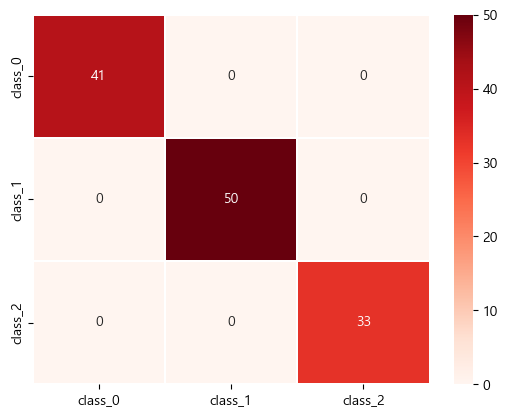

In [908]:
sb.heatmap( cmt, annot=True, fmt='d',linewidths=0.2, cmap='Reds', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.show()

In [909]:
pred_tt = m_pipeline.predict(x_test)
cmtt = confusion_matrix(y_test, pred_tt)
cmtt

array([[18,  0,  0],
       [ 0, 20,  1],
       [ 0,  0, 15]])

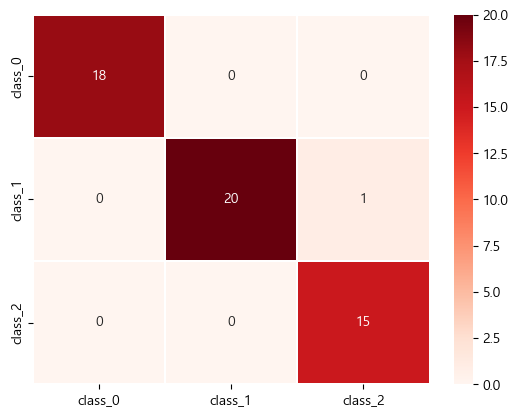

In [910]:
sb.heatmap( cmtt, annot=True, fmt='d',linewidths=0.2, cmap='Reds', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.show()

### 02. tree

In [911]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [912]:
t_pipeline = DecisionTreeClassifier()
t_pipeline.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [913]:
t_pred_t = t_pipeline.predict(x_train)
t_cmt = confusion_matrix(y_train, t_pred_t)
t_cmt

array([[41,  0,  0],
       [ 0, 50,  0],
       [ 0,  0, 33]])

In [914]:
accuracy_score( y_train, t_pred_t )

1.0

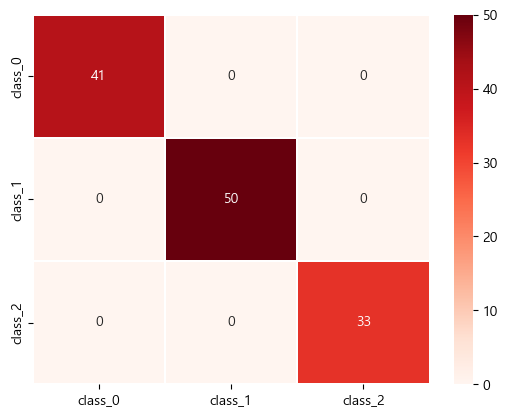

In [915]:
sb.heatmap( t_cmt, annot=True, fmt='d',linewidths=0.2, cmap='Reds', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.show()

In [916]:
t_pred_tt = t_pipeline.predict(x_test)
t_cmtt = confusion_matrix(y_test, t_pred_tt)
t_cmtt

array([[16,  2,  0],
       [ 1, 20,  0],
       [ 0,  0, 15]])

In [917]:
accuracy_score( y_test, t_pred_tt )

0.9444444444444444

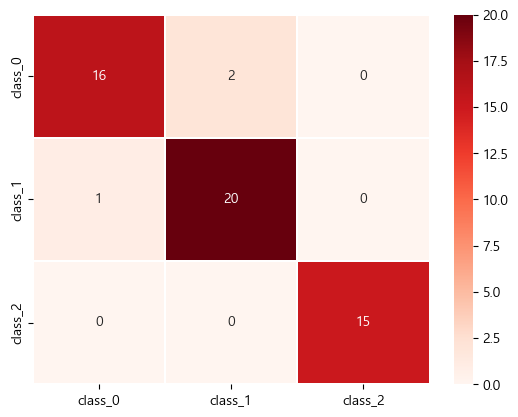

In [918]:
sb.heatmap( t_cmtt, annot=True, fmt='d',linewidths=0.2, cmap='Reds', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.show()

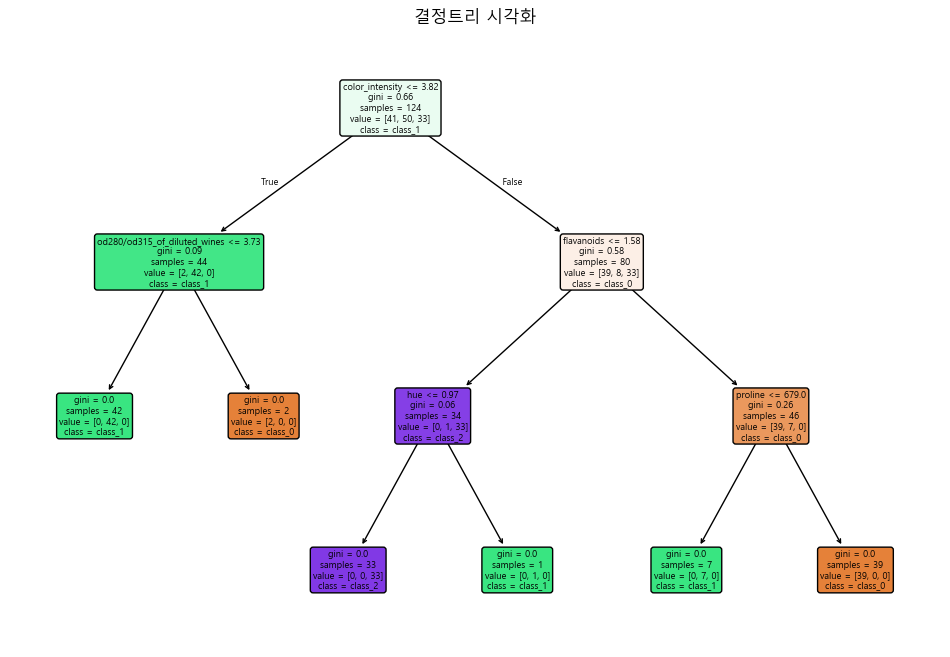

In [919]:
plt.figure( figsize=(12,8))
plot_tree( t_pipeline,  feature_names= wine['feature_names'], class_names=wine['target_names'], filled=True, rounded=True, precision=2 )
plt.title('결정트리 시각화')
plt.show()

### 03. KNN

In [920]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [921]:
param_grid={'n_neighbors':[1,2,3,4,5] }


K_pipeline = make_pipeline( StandardScaler(), GridSearchCV(KNeighborsClassifier(), param_grid=param_grid, verbose=1))
K_pipeline.fit(x_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,steps,"[('standardscaler', ...), ('gridsearchcv', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [1, 2, ...]}"
,scoring,None
,n_jobs,None


In [922]:
print( K_pipeline.named_steps['gridsearchcv'].best_params_ )

{'n_neighbors': 5}


In [923]:
k_pred_t = K_pipeline.predict(x_train)
k_cmt = confusion_matrix(y_train, k_pred_t)
k_cmt

array([[41,  0,  0],
       [ 2, 47,  1],
       [ 0,  0, 33]])

In [924]:
accuracy_score( y_train, k_pred_t )

0.9758064516129032

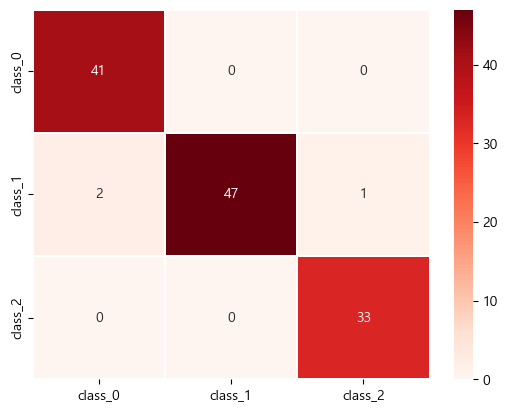

In [925]:
sb.heatmap( k_cmt, annot=True, fmt='d',linewidths=0.2, cmap='Reds', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.show()

In [926]:
k_pred_tt = K_pipeline.predict(x_test)
k_cmtt = confusion_matrix(y_test, k_pred_tt)
k_cmtt

array([[18,  0,  0],
       [ 0, 20,  1],
       [ 0,  0, 15]])

In [927]:
accuracy_score( y_test, k_pred_tt )

0.9814814814814815

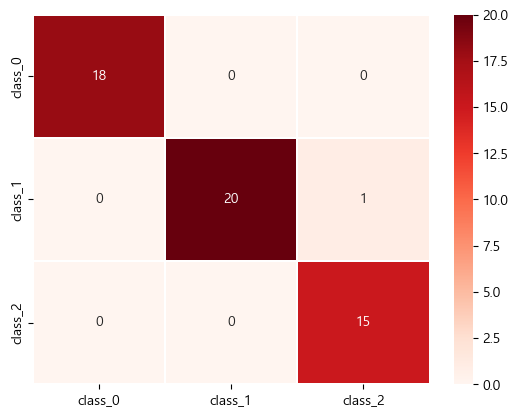

In [928]:
sb.heatmap( k_cmtt, annot=True, fmt='d',linewidths=0.2, cmap='Reds', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.show()